<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/EXERCICIO_PRATICO_MINHACONSULTA_PERCEPTRON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel('/content/table.xlsx')
print(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       Animal  Peso (kg)  Altura (cm)  Classe
0  Cachorro 1         25           60       1
1  Cachorro 2         20           55       1
2  Cachorro 3         30           65       1
3      Gato 1          5           25       0
4      Gato 2          4           20       0
5      Gato 3          6           28       0


In [12]:
# DEFINA OS PESOS E BIAS PRIMEIRO
w1 = -1
w2 = -0.03
bias = -0.1
taxa_aprendizado = 0.1

In [13]:
print("=" * 50)
print("CACHORRO 1")
print("=" * 50)
soma1 = w1 * 25 + w2 * 60 + bias
print(f"Soma: {soma1}")
if soma1 >= 0:
    predicao = 1
else:
    predicao = 0
print(f"Predição: {predicao} (1=Cachorro, 0=Gato)")
print()


print("=" * 50)
print("CACHORRO 2")
print("=" * 50)
soma2 = w1 * 20 + w2 * 55 + bias
print(f"Soma: {soma2}")
if soma2 >= 0:
    predicao = 1
else:
    predicao = 0
print(f"Predição: {predicao} (1=Cachorro, 0=Gato)")
print()

print("=" * 50)
print("CACHORRO 3")
print("=" * 50)
soma3 = w1 * 30 + w2 * 65 + bias
print(f"Soma: {soma3}")
if soma3 >= 0:
    predicao = 1
else:
    predicao = 0
print(f"Predição: {predicao} (1=Cachorro, 0=Gato)")
print()


print("=" * 50)
print("GATO 1")
print("=" * 50)
soma_gat1 = w1 * 5 + w2 * 25 + bias
print(f"Soma: {soma_gat1}")
if soma_gat1 >= 0:
    predicao = 1
else:
    predicao = 0
print(f"Predição: {predicao} (1=Cachorro, 0=Gato)")
print()


print("=" * 50)
print("GATO 2")
print("=" * 50)
soma_gat2 = w1 * 4 + w2 * 20 + bias
print(f"Soma: {soma_gat2}")
if soma_gat2 >= 0:
    predicao = 1
else:
    predicao = 0
print(f"Predição: {predicao} (1=Cachorro, 0=Gato)")
print()


print("=" * 50)
print("GATO 3")
print("=" * 50)
soma_gat3 = w1 * 6 + w2 * 28 + bias
print(f"Soma: {soma_gat3}")
if soma_gat3 >= 0:
    predicao = 1
else:
    predicao = 0
print(f"Predição: {predicao} (1=Cachorro, 0=Gato)")
print()


CACHORRO 1
Soma: -26.900000000000002
Predição: 0 (1=Cachorro, 0=Gato)

CACHORRO 2
Soma: -21.75
Predição: 0 (1=Cachorro, 0=Gato)

CACHORRO 3
Soma: -32.05
Predição: 0 (1=Cachorro, 0=Gato)

GATO 1
Soma: -5.85
Predição: 0 (1=Cachorro, 0=Gato)

GATO 2
Soma: -4.699999999999999
Predição: 0 (1=Cachorro, 0=Gato)

GATO 3
Soma: -6.9399999999999995
Predição: 0 (1=Cachorro, 0=Gato)



INICIANDO TREINAMENTO DO PERCEPTRON
Taxa de aprendizado: 0.1
Número de épocas: 50
Pesos iniciais: w1=-0.019219, w2=0.004559, bias=0.009968

ÉPOCA 1
Cachorro 1      | Peso: 25kg | Altura: 60cm | Soma: -0.1970 | Pred: Gato     | Real: Cachorro | ✗ ERROU
  └─ Ajustando pesos...
     w1: -0.019219 → 2.480781
     w2: 0.004559 → 6.004559
     bias: 0.009968 → 0.109968

Cachorro 2      | Peso: 20kg | Altura: 55cm | Soma: 379.9763 | Pred: Cachorro | Real: Cachorro | ✓ CORRETO

Cachorro 3      | Peso: 30kg | Altura: 65cm | Soma: 464.8297 | Pred: Cachorro | Real: Cachorro | ✓ CORRETO

Gato 1          | Peso:  5kg | Altura: 25cm | Soma: 162.6278 | Pred: Cachorro | Real: Gato     | ✗ ERROU
  └─ Ajustando pesos...
     w1: 2.480781 → 1.980781
     w2: 6.004559 → 3.504559
     bias: 0.109968 → 0.009968

Gato 2          | Peso:  4kg | Altura: 20cm | Soma: 78.0243 | Pred: Cachorro | Real: Gato     | ✗ ERROU
  └─ Ajustando pesos...
     w1: 1.980781 → 1.580781
     w2: 3.504559 → 1.504559
     bias: 0

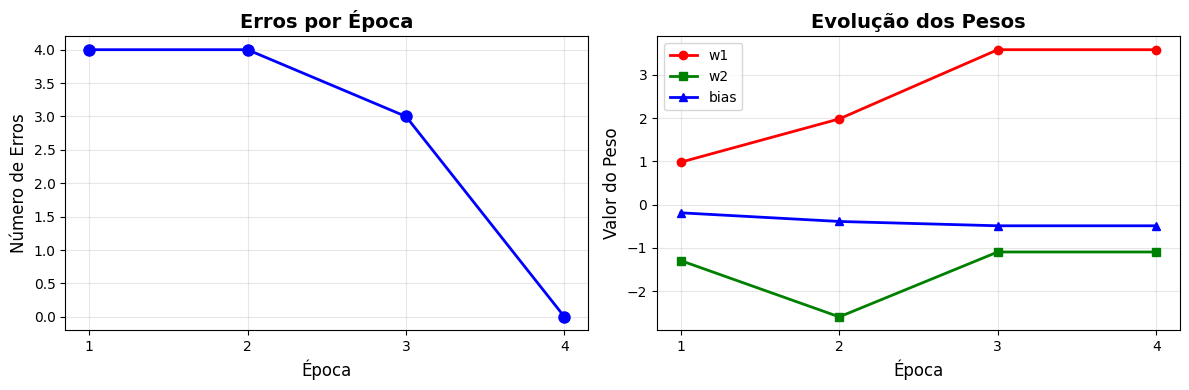

In [14]:
import numpy as np
import matplotlib.pyplot as plt

class PerceptronTreinador:
    def __init__(self, taxa_aprendizado=0.1, epocas=100):
        self.taxa_aprendizado = taxa_aprendizado
        self.epocas = epocas
        self.w1 = np.random.randn() * 0.01  # Peso para característica 1
        self.w2 = np.random.randn() * 0.01  # Peso para característica 2
        self.bias = np.random.randn() * 0.01  # Bias
        self.historico_erros = []  # Para gráfico
        self.historico_pesos = []  # Para visualizar evolução

    def funcao_ativacao(self, soma):
        """Função degrau: 1 se soma >= 0, senão 0"""
        return 1 if soma >= 0 else 0

    def prever(self, peso, altura):
        """Faz uma predição para um animal"""
        soma = self.w1 * peso + self.w2 * altura + self.bias
        predicao = self.funcao_ativacao(soma)
        return predicao, soma

    def treinar(self, dados_treino):
        """
        Treina o perceptron
        dados_treino: lista de dicionários com 'peso', 'altura' e 'classe'
        """
        print("=" * 70)
        print("INICIANDO TREINAMENTO DO PERCEPTRON")
        print("=" * 70)
        print(f"Taxa de aprendizado: {self.taxa_aprendizado}")
        print(f"Número de épocas: {self.epocas}")
        print(f"Pesos iniciais: w1={self.w1:.6f}, w2={self.w2:.6f}, bias={self.bias:.6f}")
        print()

        for epoca in range(self.epocas):
            erros_nesta_epoca = 0

            print(f"{'=' * 70}")
            print(f"ÉPOCA {epoca + 1}")
            print(f"{'=' * 70}")

            for i, animal in enumerate(dados_treino):
                peso = animal['peso']
                altura = animal['altura']
                classe_real = animal['classe']
                nome = animal['nome']

                # Faz a predição
                predicao, soma = self.prever(peso, altura)

                # Calcula o erro
                erro = classe_real - predicao

                # Mostra o resultado
                classe_pred = "Cachorro" if predicao == 1 else "Gato"
                classe_real_nome = "Cachorro" if classe_real == 1 else "Gato"
                status = "✓ CORRETO" if erro == 0 else "✗ ERROU"

                print(f"{nome:15} | Peso: {peso:2}kg | Altura: {altura:2}cm | "
                      f"Soma: {soma:7.4f} | Pred: {classe_pred:8} | "
                      f"Real: {classe_real_nome:8} | {status}")

                # Se errou, atualiza os pesos
                if erro != 0:
                    print(f"  └─ Ajustando pesos...")

                    # Mostra valores antigos
                    w1_antigo = self.w1
                    w2_antigo = self.w2
                    bias_antigo = self.bias

                    # Atualiza os pesos usando a regra do Perceptron
                    self.w1 = self.w1 + self.taxa_aprendizado * erro * peso
                    self.w2 = self.w2 + self.taxa_aprendizado * erro * altura
                    self.bias = self.bias + self.taxa_aprendizado * erro

                    # Mostra a atualização
                    print(f"     w1: {w1_antigo:8.6f} → {self.w1:8.6f}")
                    print(f"     w2: {w2_antigo:8.6f} → {self.w2:8.6f}")
                    print(f"     bias: {bias_antigo:8.6f} → {self.bias:8.6f}")

                    erros_nesta_epoca += 1

                print()

            # Registra o número de erros desta época
            self.historico_erros.append(erros_nesta_epoca)
            self.historico_pesos.append({
                'w1': self.w1,
                'w2': self.w2,
                'bias': self.bias
            })

            print(f"Total de erros na Época {epoca + 1}: {erros_nesta_epoca}")
            print()

            # Se convergiu (0 erros), para o treinamento
            if erros_nesta_epoca == 0:
                print("=" * 70)
                print(f"✓ PERCEPTRON CONVERGIU NA ÉPOCA {epoca + 1}!")
                print("=" * 70)
                print()
                break

        print("=" * 70)
        print("TREINAMENTO FINALIZADO")
        print("=" * 70)
        print(f"Pesos finais: w1={self.w1:.6f}, w2={self.w2:.6f}, bias={self.bias:.6f}")
        print()

    def testar(self, dados_teste):
        """Testa o perceptron em novos dados"""
        print("=" * 70)
        print("TESTANDO O PERCEPTRON")
        print("=" * 70)

        acertos = 0

        for animal in dados_teste:
            peso = animal['peso']
            altura = animal['altura']
            classe_real = animal['classe']
            nome = animal['nome']

            predicao, soma = self.prever(peso, altura)

            classe_pred = "Cachorro" if predicao == 1 else "Gato"
            classe_real_nome = "Cachorro" if classe_real == 1 else "Gato"

            if predicao == classe_real:
                status = "✓ CORRETO"
                acertos += 1
            else:
                status = "✗ ERROU"

            print(f"{nome:15} | Peso: {peso:2}kg | Altura: {altura:2}cm | "
                  f"Soma: {soma:7.4f} | Pred: {classe_pred:8} | "
                  f"Real: {classe_real_nome:8} | {status}")

        print()
        print(f"Acertos: {acertos}/{len(dados_teste)} ({acertos/len(dados_teste)*100:.1f}%)")
        print()

    def visualizar_treinamento(self):
        """Cria gráficos do treinamento"""
        plt.figure(figsize=(12, 4))

        # Gráfico 1: Erros por época
        plt.subplot(1, 2, 1)
        plt.plot(range(1, len(self.historico_erros) + 1),
                 self.historico_erros, 'b-o', linewidth=2, markersize=8)
        plt.xlabel('Época', fontsize=12)
        plt.ylabel('Número de Erros', fontsize=12)
        plt.title('Erros por Época', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.xticks(range(1, len(self.historico_erros) + 1))

        # Gráfico 2: Evolução dos pesos
        plt.subplot(1, 2, 2)
        w1_valores = [p['w1'] for p in self.historico_pesos]
        w2_valores = [p['w2'] for p in self.historico_pesos]
        bias_valores = [p['bias'] for p in self.historico_pesos]

        plt.plot(range(1, len(w1_valores) + 1), w1_valores, 'r-o', label='w1', linewidth=2)
        plt.plot(range(1, len(w2_valores) + 1), w2_valores, 'g-s', label='w2', linewidth=2)
        plt.plot(range(1, len(bias_valores) + 1), bias_valores, 'b-^', label='bias', linewidth=2)

        plt.xlabel('Época', fontsize=12)
        plt.ylabel('Valor do Peso', fontsize=12)
        plt.title('Evolução dos Pesos', fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.xticks(range(1, len(w1_valores) + 1))

        plt.tight_layout()
        plt.show()


# ============================================================================
# DADOS DE TREINAMENTO
# ============================================================================

dados_treino = [
    {'nome': 'Cachorro 1', 'peso': 25, 'altura': 60, 'classe': 1},
    {'nome': 'Cachorro 2', 'peso': 20, 'altura': 55, 'classe': 1},
    {'nome': 'Cachorro 3', 'peso': 30, 'altura': 65, 'classe': 1},
    {'nome': 'Gato 1', 'peso': 5, 'altura': 25, 'classe': 0},
    {'nome': 'Gato 2', 'peso': 4, 'altura': 20, 'classe': 0},
    {'nome': 'Gato 3', 'peso': 6, 'altura': 28, 'classe': 0},
]

# ============================================================================
# DADOS DE TESTE (novos animais que o perceptron nunca viu)
# ============================================================================

dados_teste = [
    {'nome': 'Novo Animal 1', 'peso': 22, 'altura': 58, 'classe': 1},  # Cachorro
    {'nome': 'Novo Animal 2', 'peso': 5.5, 'altura': 26, 'classe': 0},  # Gato
    {'nome': 'Novo Animal 3', 'peso': 28, 'altura': 62, 'classe': 1},  # Cachorro
]

# ============================================================================
# EXECUTAR O TREINAMENTO
# ============================================================================

# Cria o perceptron
perceptron = PerceptronTreinador(taxa_aprendizado=0.1, epocas=50)

# Treina o perceptron
perceptron.treinar(dados_treino)

# Testa o perceptron
perceptron.testar(dados_teste)

# Visualiza o treinamento
perceptron.visualizar_treinamento()
